In [1]:
# Load data 
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = Path(
    "../data/processed/price_distribution_15s/BTCUSDT/price_distribution_15s_BTCUSDT_2026_06_11.parquet"
)

df = pd.read_parquet(path)

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df.head()

,timestamp,price_bucket,buy_volume,sell_volume
0,2026-06-11 00:00:00+00:00,61511,0.01382,0.00000
1,2026-06-11 00:00:00+00:00,61513,0.01613,0.00000
2,2026-06-11 00:00:00+00:00,61515,0.00645,0.00000
3,2026-06-11 00:00:00+00:00,61516,0.05073,0.00214
4,2026-06-11 00:00:00+00:00,61517,0.00262,0.00000


In [2]:
#Build buy and sell matrix
#Using pivot to change from long format into wide format
#Just to show. We will build our final matrix in a more efficient way.
buy_matrix = (
    df
    .pivot(
        index="timestamp",
        columns="price_bucket",
        values="buy_volume"
    )
    .fillna(0)
)
sell_matrix = (
    df
    .pivot(
        index="timestamp",
        columns="price_bucket",
        values="sell_volume"
    )
    .fillna(0)
)

In [3]:
# 5$ steps
df["price_bucket"] = (
    df["price_bucket"] / 5
).round() * 5

In [4]:
#Exclude the trades at 00:00 the following day
day = pd.Timestamp("2026-06-11").tz_localize("UTC")

df = df.loc[
    (df["timestamp"] >= day) &
    (df["timestamp"] < day + pd.Timedelta(days=1))
]

In [5]:
agg_dict = {
    "buy_volume": "sum",
    "sell_volume": "sum",
}

df_hourly = df
df_hourly["hour"] = df_hourly["timestamp"].dt.floor("h")
df_hourly = df_hourly.groupby(["price_bucket", "hour"], as_index=False).agg(agg_dict)

In [6]:
df_hourly = df.copy()

df_hourly["hour"] = df_hourly["timestamp"].dt.floor("h")

# Aggregation and pivot in one step
volume_matrix = df_hourly.pivot_table(
    index="hour",
    columns="price_bucket",
    values=["buy_volume", "sell_volume"],
    aggfunc="sum",
    fill_value=0,
    sort=True,
)

buy_matrix = volume_matrix["buy_volume"]
sell_matrix = volume_matrix["sell_volume"]

In [7]:
#Get normalized data for the plot 
prices = buy_matrix.columns.to_numpy()
buy_values = buy_matrix.to_numpy(dtype=float)
sell_values = sell_matrix.to_numpy(dtype=float)

scales = np.maximum(
    buy_values.max(axis=1),
    sell_values.max(axis=1),
)[:, None]

# No division by 0 
scales[scales == 0] = 1

buy_normalized = buy_values / scales
sell_normalized = sell_values / scales

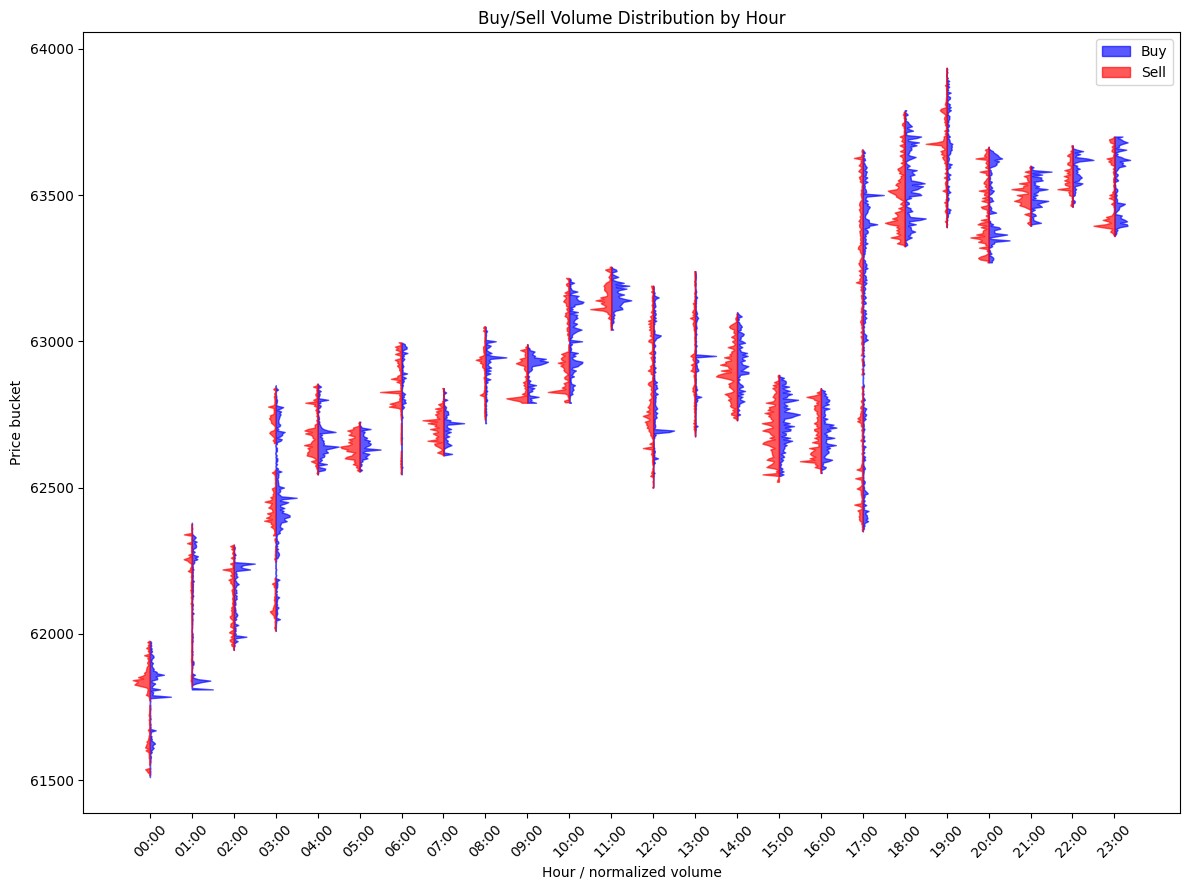

In [8]:
fig, ax = plt.subplots(figsize=(12, 9))

offset_step = 2.0
offsets = np.arange(len(buy_matrix)) * offset_step

for i, offset in enumerate(offsets):
    ax.fill_betweenx(
        prices,
        offset,
        offset + buy_normalized[i],
        where=buy_normalized[i] > 0,
        alpha=0.65,
        label="Buy" if i == 0 else None,
        color="blue"
    )

    ax.fill_betweenx(
        prices,
        offset,
        offset - sell_normalized[i],
        where=sell_normalized[i] > 0,
        alpha=0.65,
        label="Sell" if i == 0 else None,
        color="red"
    )

ax.set_xticks(offsets)
ax.set_xticklabels(
    buy_matrix.index.strftime("%H:%M"),
    rotation=45,
)

ax.set_xlabel("Hour / normalized volume")
ax.set_ylabel("Price bucket")
ax.set_title("Buy/Sell Volume Distribution by Hour")
ax.legend()

plt.tight_layout()
plt.show()